In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.optimize import curve_fit

'''
Returns a subarray, consisting of every `subset_step`th element.
Prints a summary message.
'''
def subset(data: np.ndarray, subset_step: int) -> np.ndarray:
    originl_length = len(data) # type: ignore
    data_subset = np.array(data[::subset_step]) # type: ignore
    print(f"Reduction of subsetted events: {originl_length} to {len(data_subset)}") # type: ignore
    return data_subset

'''
Returns a filtered subset of `data_to_filter`, consisting of those elements of `data_to_filter`
for which the corresponding element of `data_to_filter_on` is larger than `filter_min`.
Prints a summary message.
'''
def filter(data_to_filter: np.ndarray, data_to_filter_on: np.ndarray, filter_min: float) -> np.ndarray:
    original_length = len(data_to_filter) # type: ignore
    data_subset = np.array([datum_to_filter
        for (datum_to_filter, datum_to_filter_on) in zip(data_to_filter,data_to_filter_on)
            if datum_to_filter_on >= filter_min
    ])
    print(f"Reduction of filtered events: {original_length} to {len(data_subset)}") # type: ignore
    return data_subset

'''
Creates a histogram of `data`, scaling the data, and returning the values, and the centre points, of the bins.
'''
def histogram(data: np.ndarray, scale: float, bins: int, density: bool):
    values,bin_edges,_ = plt.hist(scale*data, bins = bins, density = density, label="time (us)")
    return values,(bin_edges[:-1] + bin_edges[1:])/2.0



In [3]:
'''
Loads the data from the nexus file, and prints a summary.
If possible, it extracts the configuration data and pretty prints it.
'''

#filepath = "archive/incoming/hifi_1/HIFI00203551.nxs"
filepath = "archive/incoming/hifi_test/HIFI00203551_dtd_20_5_10_2_extra2.nxs"
file=h5py.File(filepath,"r")

pulse_height=file["raw_data_1/detector_1/pulse_height"]
event_time_offset=file["raw_data_1/detector_1/event_time_offset"]
event_time_zero=file["raw_data_1/detector_1/event_time_zero"]
frame_number=file["raw_data_1/detector_1/frame_number"]
program_name=file["raw_data_1/program_name"]
try:
    configuration=json.loads(program_name.attrs["configuration"]) # type: ignore
    print(f"program name = {program_name[()]}") # type: ignore
    print(json.dumps(configuration, indent=4))
except:
    pass

print(f"pulse_height = {len(pulse_height)}, event_time_offset = {len(event_time_offset)}, event_time_zero = {len(event_time_zero)}") # type: ignore
#plt.plot(np.array(frame_number))


program name = b'SuperMuSR Data Pipeline Nexus Writer'
{
    "broker_settings": {
        "broker": "130.246.55.29:9092",
        "trace_to_events_group": "trace-to-events-test",
        "digitiser_aggregator_group": "digitiser-aggregator-test",
        "nexus_writer_group": "nexus-writer-test"
    },
    "topics": {
        "trace": "daq-traces-in",
        "dat_eventlists": "daq-events-test",
        "frame_eventlist": "frame-events-test",
        "control": "ics-control-change",
        "logs": "ics-metadata",
        "selogs": "HIFI_sampleEnv",
        "alarms": "ics-alarms"
    },
    "event_formation": {
        "polarity": "positive",
        "baseline": 0,
        "input_command": "differential-threshold-discriminator --threshold=20 --duration=5 --cool-off=10 --constant-multiple=2"
    },
    "digitiser_aggregator": {
        "digitisers": "-d4,5,6,7,8,9,10,11",
        "frame_ttl_ms": 200
    },
    "nexus_writer": {
        "local_host_path": "./Output/Local_test",
        "a

In [4]:
'''
We take a subset of the data so the histograms are not too slow.
These must be reduced by the same step size so their elements
still correspond with each other.
'''
event_time_offset_subset = subset(np.array(event_time_offset), subset_step=10)
pulse_height_subset = subset(np.array(pulse_height), subset_step=10)

Reduction of subsetted events: 68447207 to 6844721
Reduction of subsetted events: 68447207 to 6844721


2093.675


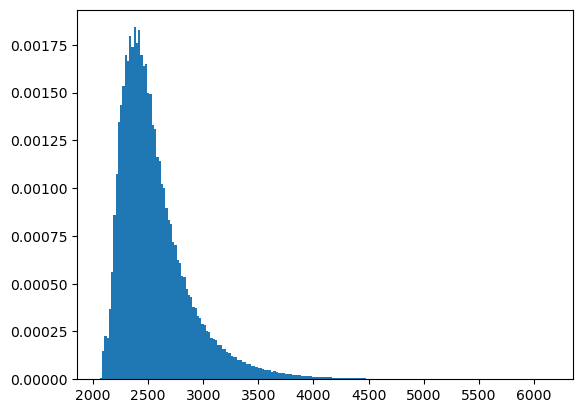

In [5]:
'''
Find the left-most local minimum of `data`.
'''
def local_min(data) -> int:
    last_value = None
    for idx, datum in enumerate(data):
        if last_value:
            if datum > last_value:
                return idx
        last_value = datum
    return 0

'''
Find the first local minimum of the pulse height data
'''
counts,bin_heights = histogram(pulse_height_subset, scale = 1.0, bins=200, density=True)
print(bin_heights[local_min(counts)])

Fitting function = 0.35593409578104784 * exp(-0.3334637642817549 * t)
Expected = 2.998826580614816 us


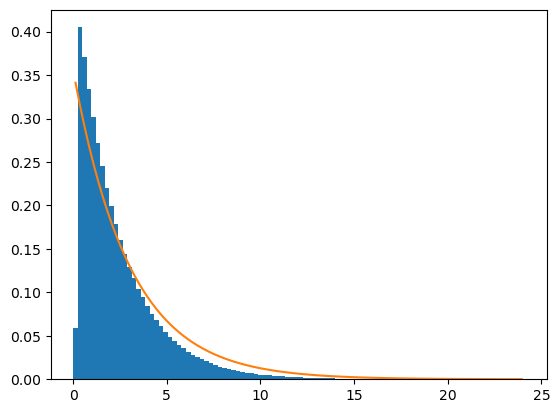

Reduction of filtered events: 6844721 to 6828672
Fitting function = 0.356059507646518 * exp(-0.3335843254466721 * t)
Expected = 2.997742770620268 us


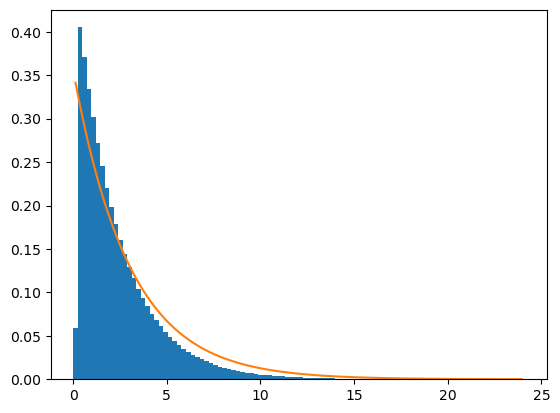

In [7]:
def exp_decay(t, ampl, decay_constant):
    return ampl*np.exp(-decay_constant * t)

def hist_and_fit_function(data):
    values,times = histogram(data, scale = 0.001, bins=100, density=True)

    params, cov = curve_fit(exp_decay, times, values)
    print(f"Fitting function = {params[0]} * exp(-{params[1]} * t)")
    print(f"Expected = {1/params[1]} us")

    plt.plot(times, exp_decay(times, params[0],params[1]))

'''
Plot a histogram of the unfiltered pulse timing data, fit an exponential decay curve and print its parameteres.
'''
hist_and_fit_function(event_time_offset_subset)
plt.show()

'''
Repeat the above with pulses filtered out if their height is below `filter_min`.
'''
#filter_min = 2210.67
filter_min = 2100
#filter_min = 0
filtered_subsetted_data = filter(data_to_filter=event_time_offset_subset, data_to_filter_on=pulse_height_subset, filter_min=filter_min)

hist_and_fit_function(filtered_subsetted_data)
